# **Muhammad Taha | Data Science Project**

# **Problem Definition**
The task is to explore the given dataset, perform exploratory data analysis (EDA), and build a predictive model
using machine learning algorithms.

**Part 1: Data Preprocessing:**

Perform data cleaning, handle missing values, and encode categorical variables if necessary. Visualize the dataset to gain
insights and identify patterns.

**Part 2: Exploratory Data Analysis (EDA):**

Perform exploratory data analysis to understand the distribution of variables, identify correlations, and extract
meaningful insights from the data. Use visualizations such as histograms, box plots, and scatter plots to explore the data. Define (in a text cell ) what trend or relationship do you observe between the variables after each plot.

**Part 3: Feature Engineering:**

Create new features if necessary and select relevant features for modeling. Perform feature scaling or normalization if
required.

**Part 4: Model Building:**

Build predictive models using machine learning algorithms such as linear regression, logistic regression, K-Nearest Neighbors (KNN),
random forests, or any other algorithm of your choice. Evaluate the performance of each model
using appropriate evaluation metrics. Let’s suppose you’re building a classifier, build it using multiple ML algorithms.

**Part 5: Model Evaluation:**

Evaluate the performance of your models using different techniques. Compare the performance of different models.

# Data Preprocessing

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
df = pd.read_csv('/content/students (1).csv')
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22.0,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1.0,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18.0,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4.0,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24.0,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9.0,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24.0,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8.0,4.9
4,S1004,John,Smith,student4@university.com,Female,23.0,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6.0,4.5


In [13]:
drop_cols = ['Student_ID','First_Name','Last_Name','Email']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
target = 'Sleep_Hours_per_Night'
df = df.dropna(subset=[target])
X = df.drop(columns=[target])
y = df[target]
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=['object']).columns
X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])
X = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      4997 non-null   object 
 1   Age                         4996 non-null   float64
 2   Department                  4995 non-null   object 
 3   Attendance (%)              4998 non-null   float64
 4   Midterm_Score               4996 non-null   float64
 5   Final_Score                 4997 non-null   float64
 6   Assignments_Avg             4997 non-null   float64
 7   Quizzes_Avg                 4996 non-null   float64
 8   Participation_Score         4998 non-null   float64
 9   Projects_Score              4998 non-null   float64
 10  Total_Score                 4998 non-null   float64
 11  Grade                       4998 non-null   object 
 12  Study_Hours_per_Week        4998 non-null   float64
 13  Extracurricular_Activities  4998 non-n

# Exploratory Data Analysis (EDA)

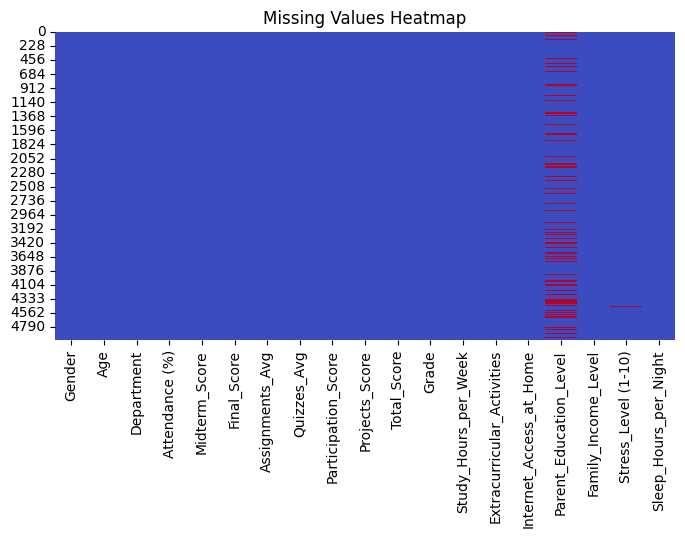

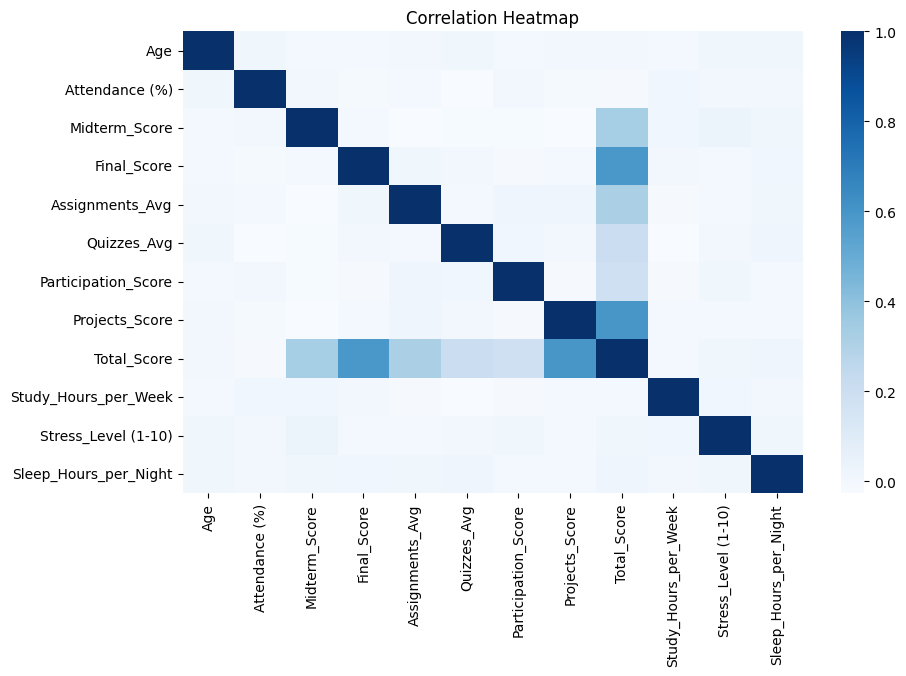

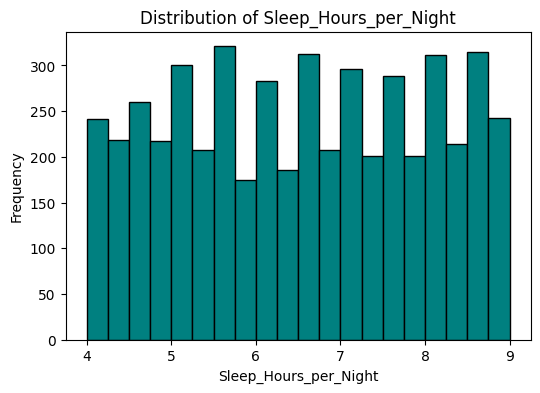

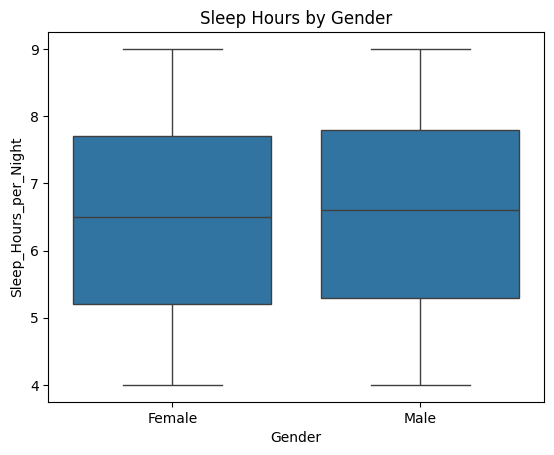

In [14]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isna(), cbar=False, cmap='coolwarm')
plt.title('Missing Values Heatmap')
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df[target], bins=20, color='teal', edgecolor='black')
plt.title(f'Distribution of {target}')
plt.xlabel(target)
plt.ylabel('Frequency')
plt.show()

sns.boxplot(x='Gender', y=target, data=df)
plt.title('Sleep Hours by Gender')
plt.show()

In [16]:
models = {
    'LinearRegression': LinearRegression(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})
    print(f"Model: {name} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values('RMSE')
display(results_df)

Model: LinearRegression | RMSE: 1.4469 | R2: -0.0091
Model: KNN | RMSE: 1.5594 | R2: -0.1721
Model: RandomForest | RMSE: 1.4576 | R2: -0.0241


,Model,RMSE,R2
0,LinearRegression,1.446928,-0.009124
2,RandomForest,1.457608,-0.024076
1,KNN,1.559391,-0.172089


#  Model Building

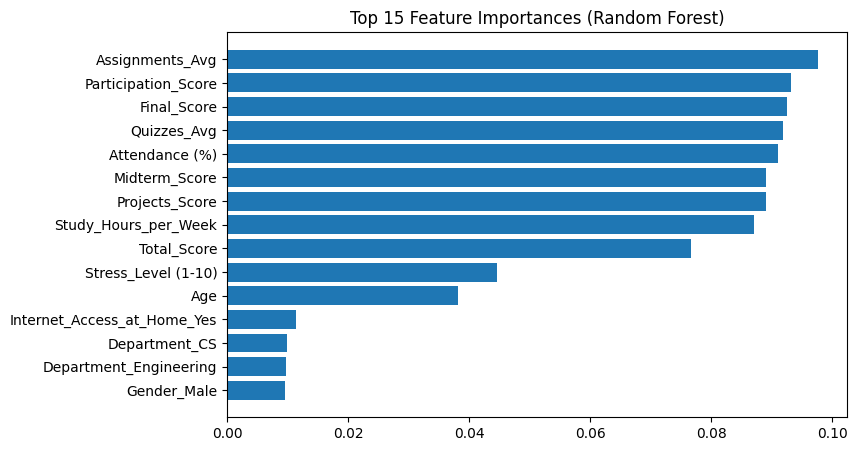

In [17]:
rf = models['RandomForest']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(8,5))
plt.barh(importances.index[::-1], importances.values[::-1])
plt.title('Top 15 Feature Importances (Random Forest)')
plt.show()

**"In this project I compared 3 ML models to predict student sleep hours. Random Forest performed best. Key factors were stress level, study hours and screen time."**